# Análisis para la reducción del churn en una aplicación fitness

**La empresa Fit.ly, una aplicación enfocada en el fitness y bienestar, ha experimentado un incremento en la tasa de abandono (churn) durante los últimos meses. Dado que la adquisición de nuevos usuarios implica un costo significativamente mayor en comparación con la retención de los clientes actuales, el objetivo de este análisis es identificar los factores que están impulsando la deserción y proponer estrategias basadas en datos que permitan mejorar la retención y optimizar el valor de vida del cliente.**



## Datos utilizados para analizar el churn en Fit.ly

Se utilizarán los siguientes datos de la empresa para identificar los factores que influyen en la pérdida de clientes y mejorar la retención:


### Tabla: customers

| Columna          | Tipo de dato | Detalles                                                          |
|------------------|-------------|--------------------------------------------------------------------|
| customer_id      | object      | Identificador único de cada cliente                                |
| email            | object      | Correo electrónico del cliente                                     |
| state            | object      | Estado de residencia del cliente                                   |
| plan             | object      | Tipo de plan contratado (básico, premium, enterprise, pro)         |
| plan_list_price  | int         | Precio específico que el cliente paga                              |
| churn_status     | object      | Estado del cliente (Y = abandonó, Nan = permanece activo)          |

### Tabla: support_tickets

| Columna                | Tipo de dato | Detalles                                                                 |
|------------------------|--------------|-------------------------------------------------------------------------|
| ticket_time            | object       | Tiempo registrado del ticket                                            |
| user_id                | int          | Identificador único del usuario                                         |
| channel                | object       | Canal de atención (chat, email, etc.)                                   |
| topic                  | object       | Tema del ticket (técnico, facturación, etc.)                            |
| resolution_time_hours  | float        | Tiempo de resolución del ticket en horas                                |
| state                  | int          | Estado del ticket (ej. 1 = resuelto, 0 = pendiente)                     |
| comments               | object       | Comentarios adicionales del soporte o del usuario                       |

### Tabla: user_events

| Columna    | Tipo de dato | Detalles                                                      |
|------------|--------------|--------------------------------------------------------------|
| event_time | object       | Tiempo en el que ocurre el evento                            |
| user_id    | int          | Identificador único del usuario                              |
| event_type | object       | Tipo de evento (ej. watch_video, login, workout, etc.)       |

# Importar  librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importar tablas

In [2]:
account = pd.read_csv("da_fitly_account_info.csv")
customer = pd.read_csv("da_fitly_customer_support.csv")
user_activity = pd.read_csv("da_fitly_user_activity.csv")

# Validación de datos 

Revisar las columnas para analizar cómo están relacionadas entre sí

In [3]:
customer.head(5)

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
2,2025-08-22 12:39:35.718663,10149,chat,technical,10.09,0,Erase my data from your systems.
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN


In [4]:
account.head(5)

,customer_id,email,state,plan,plan_list_price,churn_status
0,C10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,C10001,user10001@example.net,Louisiana,Basic,22,Y
2,C10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,C10003,user10003@example.com,Michigan,Free,0,NaN
4,C10004,user10004@example.com,Texas,Enterprise,119,NaN


In [5]:
user_activity.head(5)

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
1,2025-09-08 08:15:05.264103,10220,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout


Existe una columna adicional en la tabla de clientes que no está incluida en la documentación, por lo que debería agregarse la columna comentarios. Asimismo, en la tabla de account, la columna se denomina churn_status, mientras que en la documentación aparece como churn.

También se observó que, en la tabla account, los usuarios están identificados como customer_id, a diferencia de las otras dos tablas donde se etiquetan como user_id. Además, los IDs en customer_id incluyen una ‘C’ al inicio, mientras que user_id no. Por lo tanto, se realiza una modificación para estandarizar tanto la nomenclatura como el formato.

In [6]:
account.rename(columns= {'customer_id':'user_id'}, inplace=True)

In [7]:
account['user_id'] = account['user_id'].str.replace('C', '')

In [8]:
account.head(5)

,user_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,10001,user10001@example.net,Louisiana,Basic,22,Y
2,10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,10003,user10003@example.com,Michigan,Free,0,NaN
4,10004,user10004@example.com,Texas,Enterprise,119,NaN


Se eliminan los datos de los usuarios que lo solicitaron

In [9]:
comments = customer[customer['comments'].notna()]

In [10]:
comments.sort_values(by='user_id')

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
246,2025-09-29 00:47:34.555992,10018,phone,other,10.99,1,Request deletion of all records.
685,2025-09-29 04:19:27.309392,10020,phone,technical,7.32,0,Request full personal data deletion.
116,2025-06-21 02:30:07.621868,10029,phone,account,10.71,0,Erase my data from your systems.
450,2025-09-18 06:10:55.088177,10032,phone,other,27.90,0,Please delete all my personal data.
39,2025-10-06 13:36:20.025866,10038,phone,account,16.97,0,Wipe all data you hold.
207,2025-07-27 08:37:07.382921,10065,email,other,18.02,0,Remove my personal records.
630,2025-06-08 23:58:57.151845,10085,chat,account,20.97,0,Delete my information entirely.
568,2025-06-15 00:14:50.180863,10091,email,other,17.88,0,Request to remove my data.
365,2025-10-05 06:42:48.182797,10095,chat,account,8.15,1,Wipe all data you hold.
433,2025-07-05 22:07:54.841370,10103,email,other,7.45,0,Requesting right to be forgotten.


Se crea una lista de usuarios que solicitaron la eliminación de sus datos para eliminarlos en las demás tablas si es que tienen información de esos usuarios

In [11]:
users_to_delete = comments['user_id'].unique()

In [12]:
users_to_delete

array([10149, 10117, 10038, 10364, 10134, 10374, 10029, 10187, 10269,
       10151, 10065, 10221, 10266, 10018, 10168, 10329, 10342, 10331,
       10209, 10095, 10103, 10032, 10229, 10234, 10193, 10382, 10356,
       10091, 10135, 10322, 10299, 10085, 10020, 10203, 10272, 10350,
       10389, 10111, 10128, 10220, 10304, 10162, 10255])

In [13]:
len(users_to_delete)

43

Los datos se eliminan de la tabla customer

In [14]:
customer = customer[customer['comments'].isna()]

In [15]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            872 non-null    object 
 1   user_id                872 non-null    int64  
 2   channel                872 non-null    object 
 3   topic                  872 non-null    object 
 4   resolution_time_hours  872 non-null    float64
 5   state                  872 non-null    int64  
 6   comments               0 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 54.5+ KB


Se verifica si esos usuarios tienen datos en las otras tablas

In [16]:
account.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 18.9+ KB


In [17]:
account = account[~account['user_id'].isin(users_to_delete)]

In [18]:
account.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 21.9+ KB


In [19]:
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  445 non-null    object
 1   user_id     445 non-null    int64 
 2   event_type  445 non-null    object
dtypes: int64(1), object(2)
memory usage: 10.6+ KB


In [20]:
user_activity = user_activity[~user_activity['user_id'].isin(users_to_delete)]

In [21]:
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 401 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  401 non-null    object
 1   user_id     401 non-null    int64 
 2   event_type  401 non-null    object
dtypes: int64(1), object(2)
memory usage: 12.5+ KB


# Limpieza de los datos

se revisa la tabla customer

In [22]:
customer.head(5)

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments
0,2025-06-13 05:55:17.154573,10125,chat,technical,11.48,1,NaN
1,2025-08-06 13:21:54.539551,10109,chat,account,1.01,0,NaN
3,2025-06-07 02:49:46.986055,10268,phone,account,9.10,1,NaN
4,2025-07-25 00:24:38.945079,10041,phone,other,2.28,1,NaN
5,2025-08-19 03:23:03.240394,10066,phone,technical,0.53,1,NaN


In [23]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ticket_time            872 non-null    object 
 1   user_id                872 non-null    int64  
 2   channel                872 non-null    object 
 3   topic                  872 non-null    object 
 4   resolution_time_hours  872 non-null    float64
 5   state                  872 non-null    int64  
 6   comments               0 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 54.5+ KB


In [24]:
customer.describe()

,user_id,resolution_time_hours,state
count,872.000000,872.000000,872.000000
mean,10201.638761,10.325780,0.555046
std,116.231060,7.086759,0.497246
min,10000.000000,0.520000,0.000000
25%,10102.750000,4.980000,0.000000
50%,10205.500000,8.965000,1.000000
75%,10302.000000,12.877500,1.000000
max,10399.000000,32.460000,1.000000


El tipo de dato de ticket_time se convierte a fecha

In [25]:
customer['ticket_time'] = pd.to_datetime(customer['ticket_time'])

In [26]:
customer['ticket_time'].nunique()

872

Se revisa la columna user_id por valores duplicados

In [28]:
customer[customer.duplicated(keep=False)]

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments


En la columna channel, el valor “-” se convierte a NaN para facilitar el análisis y la visualización

In [29]:
customer['channel'].unique()

array(['chat', 'phone', '-', 'email'], dtype=object)

In [30]:
customer['channel'] = customer['channel'].replace('-', np.nan)

In [31]:
customer['channel'].unique()

array(['chat', 'phone', nan, 'email'], dtype=object)

In [32]:
customer['channel'] = customer['channel'].astype('category')

In [33]:
customer['channel'].unique()

['chat', 'phone', NaN, 'email']
Categories (3, object): ['chat', 'email', 'phone']

Se revisan las demás columnas

In [34]:
customer['topic'].unique()

array(['technical', 'account', 'other', 'billing'], dtype=object)

In [35]:
customer['topic'] = customer['topic'].astype('category')

In [36]:
customer['resolution_time_hours'].describe()

count    872.000000
mean      10.325780
std        7.086759
min        0.520000
25%        4.980000
50%        8.965000
75%       12.877500
max       32.460000
Name: resolution_time_hours, dtype: float64

In [37]:
customer['state'].unique()

array([1, 0])

Se verifica si existen filas duplicadas

In [38]:
customer[customer.duplicated(keep=False)]

,ticket_time,user_id,channel,topic,resolution_time_hours,state,comments


In [39]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 872 entries, 0 to 917
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ticket_time            872 non-null    datetime64[ns]
 1   user_id                872 non-null    int64         
 2   channel                834 non-null    category      
 3   topic                  872 non-null    category      
 4   resolution_time_hours  872 non-null    float64       
 5   state                  872 non-null    int64         
 6   comments               0 non-null      object        
dtypes: category(2), datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 42.9+ KB


Se continúa con la verificación de la tabla account

La columna signup_date no está presente, aunque sí se encuentra especificada en la documentación

In [40]:
account.head(5)

,user_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,10001,user10001@example.net,Louisiana,Basic,22,Y
2,10002,user10002@example.net,Oklahoma,Basic,24,NaN
3,10003,user10003@example.com,Michigan,Free,0,NaN
4,10004,user10004@example.com,Texas,Enterprise,119,NaN


In [41]:
account.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          400 non-null    object
 1   email            400 non-null    object
 2   state            400 non-null    object
 3   plan             400 non-null    object
 4   plan_list_price  400 non-null    int64 
 5   churn_status     114 non-null    object
dtypes: int64(1), object(5)
memory usage: 21.9+ KB


In [42]:
account.describe()

,plan_list_price
count,400.000000
mean,43.965000
std,45.263348
min,0.000000
25%,0.000000
50%,26.000000
75%,77.250000
max,148.000000


La columna churn_status se renombra como churn para alinearse con la documentación

In [43]:
account = account.rename(columns={'churn_status':'churn'})

El tipo de dato de user_id se convierte a entero

In [44]:
account['user_id'] = account['user_id'].astype('int')

Se verifica que el número de estados sea correcto

In [45]:
account['state'].nunique()

50

In [46]:
account['state'] = account['state'].astype('category')

Se verifica que únicamente se incluyan los planes válidos de la empresa

In [47]:
account['plan'].unique()

array(['Enterprise', 'Basic', 'Free', 'Pro'], dtype=object)

In [48]:
account['plan'] = account['plan'].astype('category')

La columna churn se convierte a un valor entero (1 = churn, 0 = no churn)

In [49]:
account['churn'].unique()

array(['Y', nan], dtype=object)

In [50]:
account['churn'] = account['churn'].apply(lambda x: 1 if x == 'Y' else 0)

Se verifica si existen filas duplicadas

In [51]:
account[account.duplicated(keep=False)]

,user_id,email,state,plan,plan_list_price,churn


In [52]:
account.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   user_id          400 non-null    int64   
 1   email            400 non-null    object  
 2   state            400 non-null    category
 3   plan             400 non-null    category
 4   plan_list_price  400 non-null    int64   
 5   churn            400 non-null    int64   
dtypes: category(2), int64(3), object(1)
memory usage: 19.1+ KB


La limpieza continúa con la tabla user_activity

In [53]:
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 401 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   event_time  401 non-null    object
 1   user_id     401 non-null    int64 
 2   event_type  401 non-null    object
dtypes: int64(1), object(2)
memory usage: 12.5+ KB


In [54]:
user_activity.describe()

,user_id
count,401.000000
mean,10198.139651
std,115.027955
min,10000.000000
25%,10106.000000
50%,10197.000000
75%,10295.000000
max,10396.000000


In [55]:
user_activity.head(5)

,event_time,user_id,event_type
0,2025-09-08 15:05:39.422721,10118,watch_video
2,2025-11-14 06:28:35.207671,10009,share_workout
3,2025-08-20 16:53:38.682901,10227,read_article
4,2025-07-24 16:47:31.728422,10123,track_workout
5,2025-10-07 20:16:39.779447,10073,track_workout


Se convierte el tipo de dato de event_time

In [56]:
user_activity['event_time'] = pd.to_datetime(user_activity['event_time'])

In [57]:
user_activity['event_time'].describe()

count                            401
unique                           401
top       2025-09-08 15:05:39.422721
freq                               1
first     2025-06-05 10:14:53.039663
last      2025-12-01 21:12:13.342817
Name: event_time, dtype: object

“Se valida la columna event_type y se convierte a tipo de dato categórico

In [58]:
user_activity['event_type'].unique()

array(['watch_video', 'share_workout', 'read_article', 'track_workout'],
      dtype=object)

In [59]:
user_activity['event_type'] = user_activity['event_type'].astype('category')

In [60]:
user_activity.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 401 entries, 0 to 444
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   event_time  401 non-null    datetime64[ns]
 1   user_id     401 non-null    int64         
 2   event_type  401 non-null    category      
dtypes: category(1), datetime64[ns](1), int64(1)
memory usage: 10.0 KB


Se verifica si existen filas duplicadas

In [61]:
user_activity[user_activity.duplicated(keep=False)]

,event_time,user_id,event_type


# Analisis exploratorio 

Se analizarán los factores que llevan a los usuarios a churn

Total de usuarios agrupados por categoría de churn

In [62]:
churn_counts = account['churn'].value_counts()

Text(0, 0.5, '')

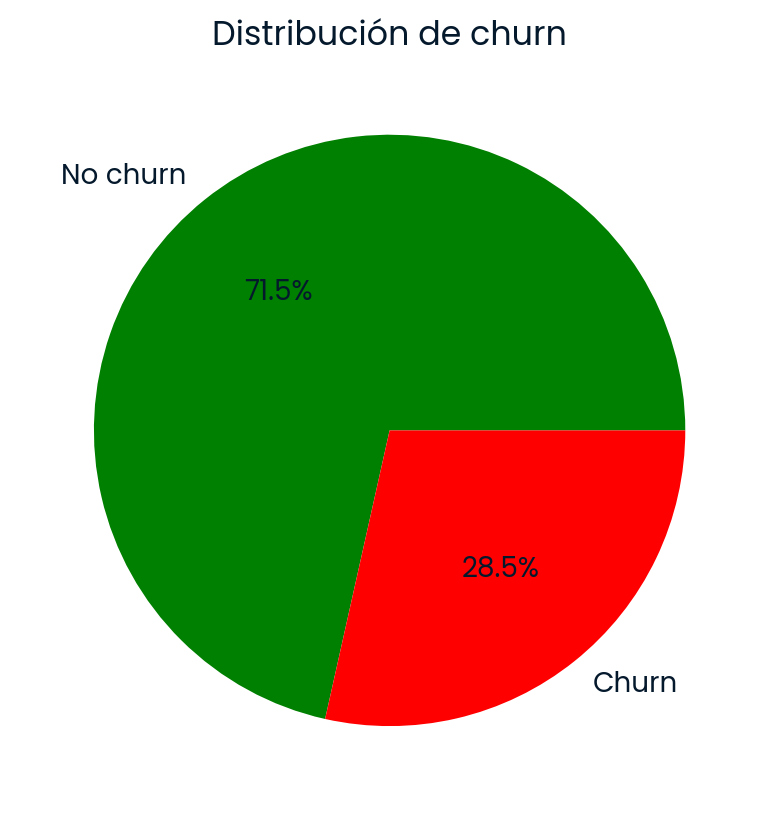

In [103]:
churn_counts.plot(kind='pie', labels=['No churn', 'Churn'], autopct='%1.1f%%', colors=['green', 'red'])

plt.title('Distribución de churn')
plt.ylabel('')

In [64]:
customers_per_plan = account['plan'].value_counts()

Text(0, 0.5, 'numero de clientes')

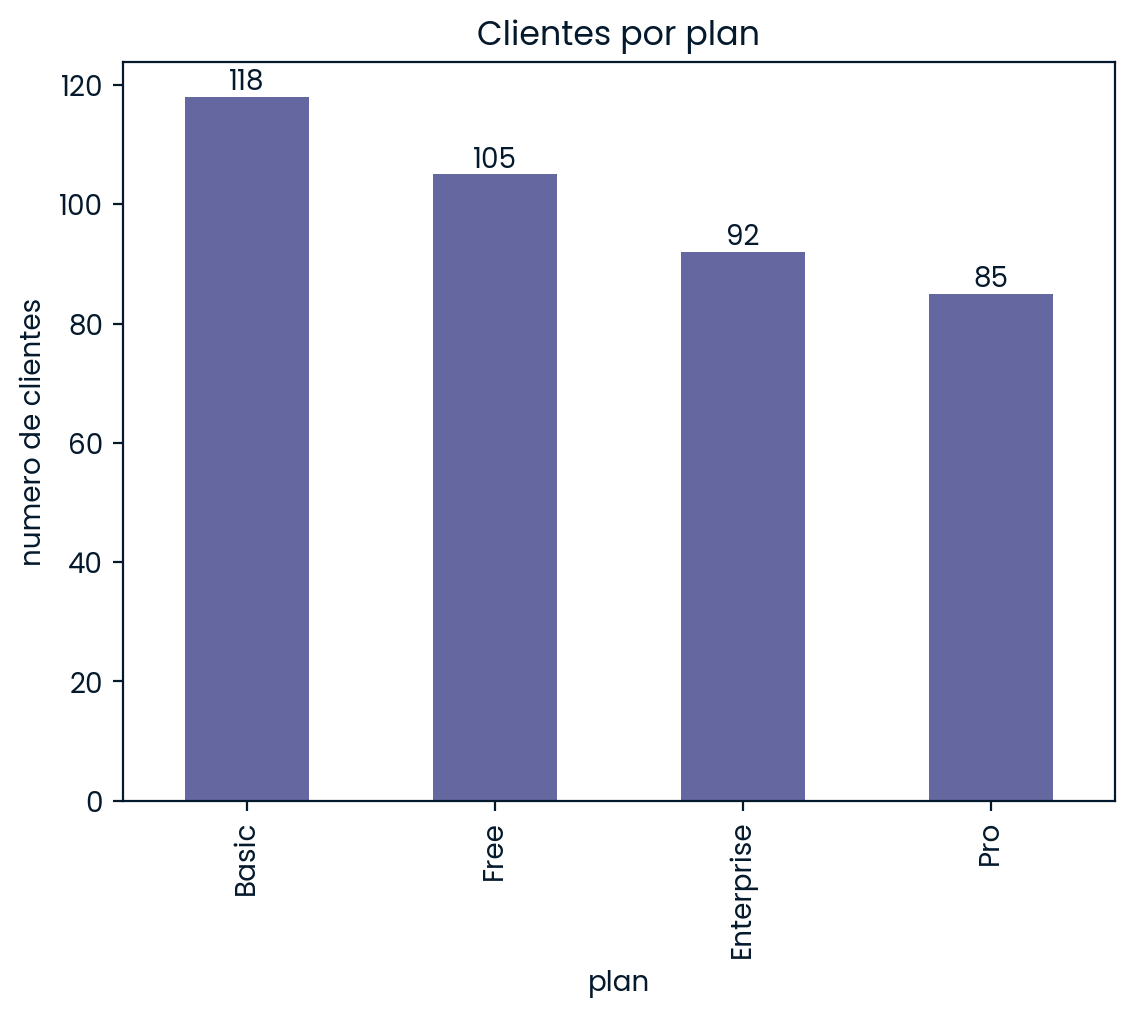

In [104]:
ax = customers_per_plan.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Clientes por plan')
plt.xlabel('plan')
plt.ylabel('numero de clientes')

The relationship between users’ plan types and churn is analyzed

In [66]:
churn_plan = account.groupby(['plan','churn']).size().unstack()

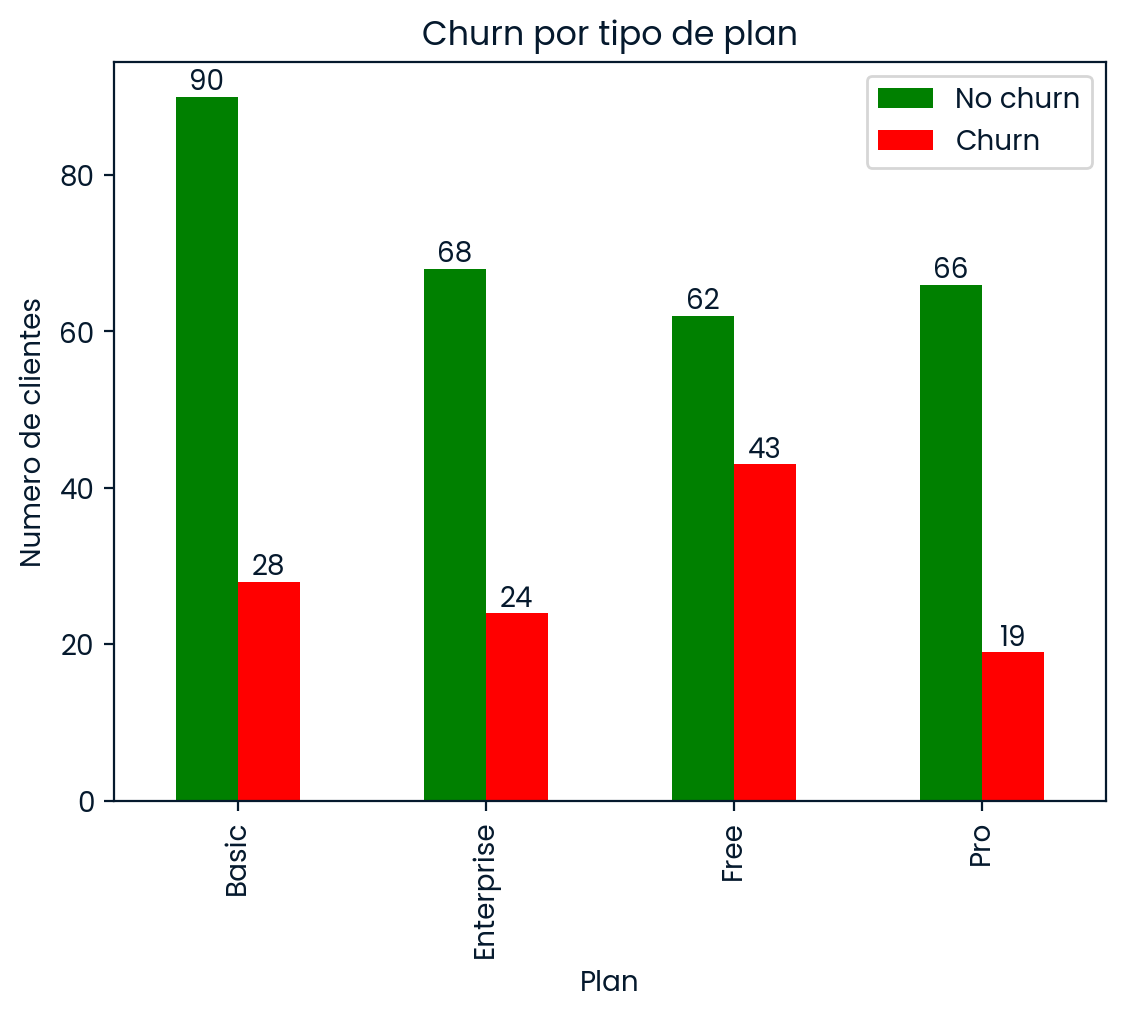

In [105]:
ax = churn_plan.plot(kind='bar', color=['green', 'red'])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn por tipo de plan')
plt.xlabel('Plan')
plt.ylabel('Numero de clientes')
plt.legend(['No churn', 'Churn'])

El análisis muestra que el churn más alto se presenta entre los usuarios del plan gratuito. Se recomienda implementar incentivos para motivar a los usuarios a cambiar a planes de pago.

In [68]:
churn_plan_price = account.groupby(['plan','churn'])['plan_list_price'].mean().round(2)

In [69]:
churn_plan_price.sort_values()

plan        churn
Free        0          0.00
            1          0.00
Basic       0         19.84
            1         19.96
Pro         1         50.11
            0         54.79
Enterprise  0        114.34
            1        120.75
Name: plan_list_price, dtype: float64

No se observa una diferencia considerable en el precio entre los usuarios que hicieron churn y los que se mantuvieron, independientemente del tipo de plan

### A continuación, se analiza la relación entre el churn y las actividades de los usuarios

Se realiza un análisis para determinar si el tiempo transcurrido desde la última actividad del usuario influye en el churn

In [70]:
user_activity['user_id'].nunique()

222

In [71]:
last_activity = user_activity.groupby('user_id')['event_time'].max().reset_index()

In [72]:
user_activity_churn = pd.merge(last_activity, account[['user_id', 'plan', 'churn']], on='user_id', how='inner'                       )

In [73]:
user_activity_churn.groupby('churn')['event_time'].mean()

churn
0   2025-09-30 05:06:08.848921856
1   2025-09-10 11:37:38.982376448
Name: event_time, dtype: datetime64[ns]

In [74]:
reference_date = user_activity_churn[user_activity_churn['churn'] == 0]['event_time'].mean()

user_activity_churn['days_inactive'] = (reference_date  - user_activity_churn['event_time']).dt.days

In [75]:
reference_date

Timestamp('2025-09-30 05:06:08.848921600')

In [76]:
days_churn = user_activity_churn.groupby('churn')['days_inactive'].mean()

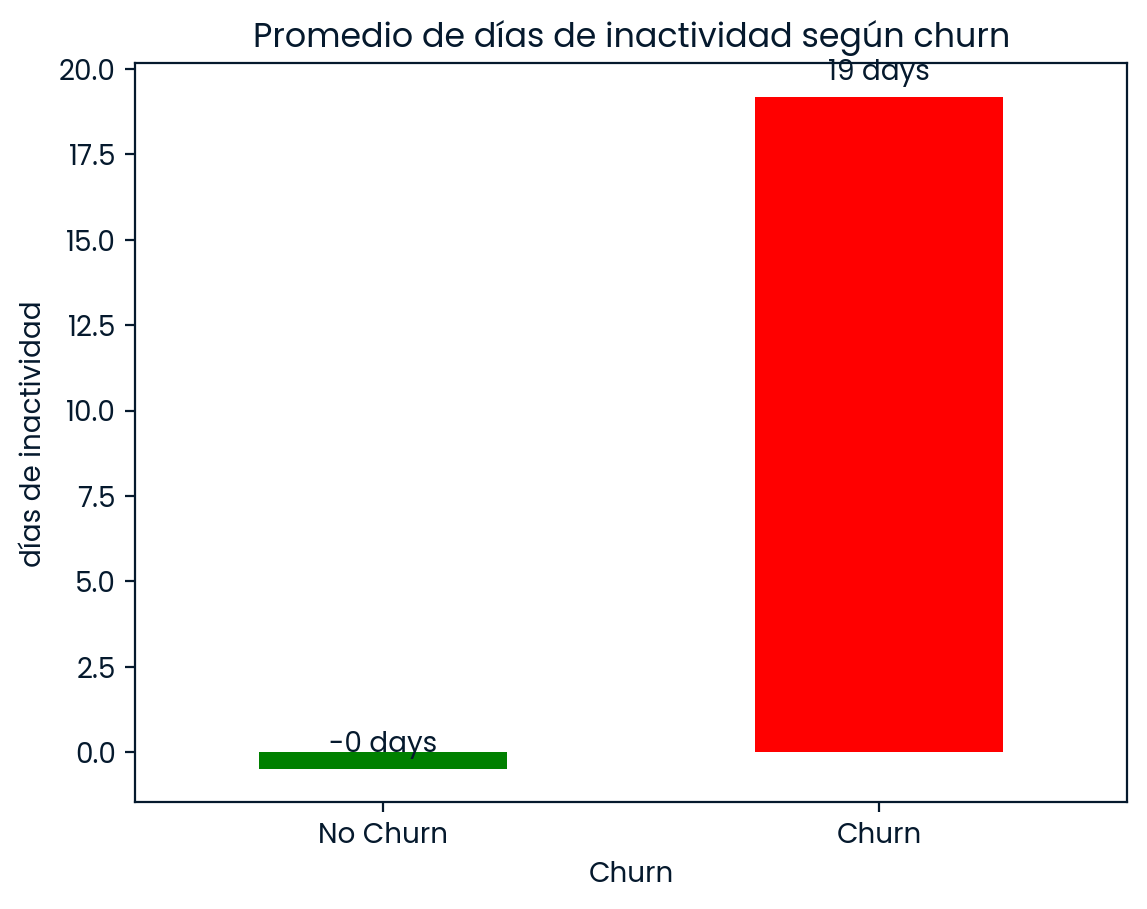

In [108]:
days_churn.plot(kind='bar', color=['green', 'red'])

plt.title('Promedio de días de inactividad según churn')
plt.xlabel('Churn')
plt.ylabel('días de inactividad')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)

for i, v in enumerate(days_churn):
    plt.text(i, v + 0.5, f'{v:.0f} days', ha='center')

plt.show()

Los usuarios que hicieron churn presentan, en promedio, 20 días más de inactividad en comparación con aquellos que no hicieron churn

In [78]:
user_churn_per_plan = user_activity_churn.groupby(['churn', 'plan'])['event_time'].mean()

user_churn_per_plan.sort_values()

churn  plan      
1      Free         2025-08-22 01:46:54.705569024
       Enterprise   2025-09-15 19:08:12.941779712
       Basic        2025-09-22 16:44:00.524876800
0      Free         2025-09-24 11:03:42.920624128
       Enterprise   2025-09-24 19:49:00.930125312
       Pro          2025-09-25 12:43:26.702998528
1      Pro          2025-10-07 13:46:47.490741504
0      Basic        2025-10-10 23:34:21.247200768
Name: event_time, dtype: datetime64[ns]

Por plan, los usuarios del plan gratuito son los más afectados, con un promedio de un mes de inactividad entre quienes hicieron churn. Los usuarios de los planes Basic y Enterprise también se ven impactados, mientras que los usuarios del plan Pro parecen menos afectados, aunque se requiere más información para confirmarlo

Determinar si el churn está influenciado por el número de eventos que realiza el usuario

In [79]:
events_per_user = user_activity.groupby('user_id').size().reset_index(name='num_events')

In [80]:
events_per_user = events_per_user.merge( account[['user_id', 'churn', 'plan']], on='user_id', how='inner')

In [81]:
events_per_user.head(5)

,user_id,num_events,churn,plan
0,10000,3,1,Enterprise
1,10001,1,1,Basic
2,10002,1,0,Basic
3,10003,1,0,Free
4,10004,4,0,Enterprise


In [82]:
events_per_user.groupby('churn')['num_events'].mean().round(2)

churn
0    1.87
1    1.33
Name: num_events, dtype: float64

In [83]:
events_per_user.groupby(['plan', 'churn'])['num_events'].mean().round(2)

plan        churn
Basic       0        1.80
            1        1.67
Enterprise  0        2.02
            1        1.67
Free        0        1.87
            1        1.09
Pro         0        1.81
            1        1.00
Name: num_events, dtype: float64

La frecuencia de actividad del usuario (número de eventos) tiene un impacto en el churn; esto se aplica a todos los planes

### A continuación, se analiza la relación entre el churn de los usuarios y la actividad de soporte

In [84]:
support = customer.groupby('user_id').agg({
    'state': ['mean', 'sum', 'count'], 'resolution_time_hours': 'sum'})

support.columns = ['resolution_rate', 'resolved_tickets', 'total_tickets', 'resolution_time_hours']
support = support.reset_index()

In [85]:
support['resolution_rate'] = support['resolution_rate'].round(2)

In [86]:
support.head()

,user_id,resolution_rate,resolved_tickets,total_tickets,resolution_time_hours
0,10000,0.67,2,3,64.34
1,10001,0.75,3,4,70.17
2,10002,0.67,2,3,19.30
3,10003,1.00,1,1,2.19
4,10004,0.50,2,4,34.17


In [87]:
support_churn = pd.concat([account[['user_id', 'plan', 'churn']], support[['resolution_rate', 'resolved_tickets', 'total_tickets', 'resolution_time_hours']]], axis=1)

In [88]:
support_churn.groupby(['churn'])['resolution_rate'].mean().round(2)

churn
0    0.56
1    0.58
Name: resolution_rate, dtype: float64

In [89]:
support_churn.groupby(['churn', 'plan'])['resolution_rate'].mean().round(2)

churn  plan      
0      Basic         0.55
       Enterprise    0.56
       Free          0.53
       Pro           0.58
1      Basic         0.50
       Enterprise    0.58
       Free          0.57
       Pro           0.70
Name: resolution_rate, dtype: float64

Se analiza si existe relación entre el tiempo de resolución de los tickets de soporte y el churn

In [90]:
support_churn.groupby(['churn'])['resolution_time_hours'].mean().round(2)

churn
0    23.14
1    29.30
Name: resolution_time_hours, dtype: float64

[Text(0, 0, '23.14'), Text(0, 0, '29.3')]

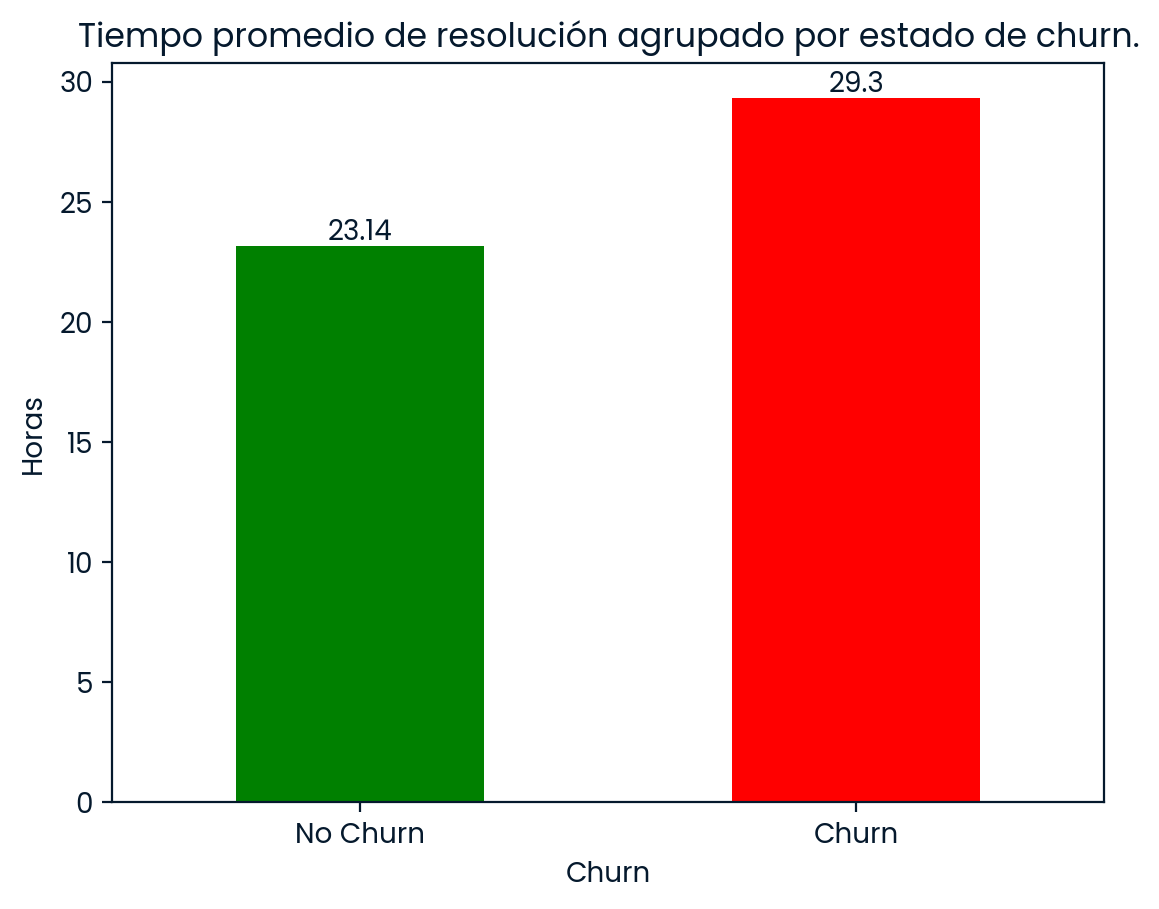

In [110]:
churn_for_problem_resolution = support_churn.groupby('churn')['resolution_time_hours'].mean().round(2)

ax = churn_for_problem_resolution.plot(kind='bar', color=['green', 'red'])

plt.title('Tiempo promedio de resolución agrupado por estado de churn.')
plt.xlabel('Churn')
plt.ylabel('Horas')
plt.xticks([0, 1], ['No Churn', 'Churn'], rotation=0)

# Labels encima de las barras
ax.bar_label(ax.containers[0])

Parece existir una relación entre el tiempo que los usuarios dedican a los tickets de soporte (y su resolución) y el churn, especialmente entre los usuarios del plan Pro

Los usuarios que hicieron churn presentan un tiempo de resolución un 26.6% mayor

In [92]:
support_churn.groupby(['churn', 'plan'])['resolution_time_hours'].mean().round(2)

churn  plan      
0      Basic         24.13
       Enterprise    21.78
       Free          28.57
       Pro           18.34
1      Basic         30.27
       Enterprise    27.93
       Free          32.15
       Pro           23.81
Name: resolution_time_hours, dtype: float64

Se observa el mismo patrón entre los clientes de los diferentes tipos de plan

In [93]:
support_churn.groupby(['churn'])['total_tickets'].mean().round(2)

churn
0    2.32
1    2.63
Name: total_tickets, dtype: float64

In [94]:
support_churn.groupby(['churn', 'plan'])['total_tickets'].mean().round(2)

churn  plan      
0      Basic         2.33
       Enterprise    2.24
       Free          2.41
       Pro           2.32
1      Basic         2.61
       Enterprise    2.22
       Free          2.79
       Pro           2.83
Name: total_tickets, dtype: float64

Se realiza un análisis para determinar si el tema de los tickets influye en el churn

In [95]:
customer_topic = customer.groupby('topic').agg({'state': ['mean', 'count']})

customer_topic.columns = ['resolution_rate', 'total_tickets']
customer_topic = customer_topic.reset_index()

In [96]:
customer_topic

,topic,resolution_rate,total_tickets
0,account,0.534884,215
1,billing,0.596491,228
2,other,0.544186,215
3,technical,0.542056,214


In [97]:
topic_problem = pd.concat([account[['user_id', 'plan', 'churn']],customer[['topic', 'state', 'resolution_time_hours']]], axis=1)

In [98]:
topic_problem.groupby('topic')['churn'].mean().round(2)

topic
account      0.28
billing      0.29
other        0.25
technical    0.31
Name: churn, dtype: float64

In [99]:
topic_problem.groupby(['topic', 'plan'])['churn'].mean().round(2)

topic      plan      
account    Basic         0.32
           Enterprise    0.19
           Free          0.35
           Pro           0.23
billing    Basic         0.25
           Enterprise    0.25
           Free          0.37
           Pro           0.28
other      Basic         0.17
           Enterprise    0.23
           Free          0.48
           Pro           0.10
technical  Basic         0.23
           Enterprise    0.38
           Free          0.40
           Pro           0.27
Name: churn, dtype: float64

In [100]:
topic_user = topic_problem.groupby(['user_id', 'topic']).agg({'state': 'min', 'churn': 'max'}).reset_index()

In [101]:
topic_user.groupby(['topic', 'state'])['churn'].mean().round(2)

topic      state
account    0.0      0.32
           1.0      0.25
billing    0.0      0.33
           1.0      0.27
other      0.0      0.20
           1.0      0.28
technical  0.0      0.36
           1.0      0.28
Name: churn, dtype: float64

In [102]:
topic_user.groupby(['state'])['churn'].mean().round(2)

state
0.0    0.30
1.0    0.27
Name: churn, dtype: float64

# Principales hallazgos

## Los usuarios que hicieron churn presentan niveles de inactividad significativamente mayores en comparación con los usuarios que no hicieron churn

En promedio, los usuarios que hicieron churn muestran aproximadamente 20 días adicionales de inactividad en relación con la línea base definida por los usuarios que no hicieron churn.

## Los usuarios que hicieron churn experimentan tiempos de resolución de soporte más largos, lo que indica posible fricción en la atención al cliente

El tiempo promedio de resolución para los usuarios que hicieron churn es aproximadamente 26.6% mayor, equivalente a alrededor de 6 horas adicionales, en comparación con los usuarios que no hicieron churn.

## Factores secundarios (monitorear, pero no son los impulsores principales)

## Las tasas de churn varían significativamente según el plan de suscripción, siendo los usuarios del plan gratuito los que presentan un churn considerablemente más alto

Aproximadamente el 40% de los usuarios del plan gratuito hacen churn, en comparación con un 22%–26% en los planes de pago (Basic, Pro, Enterprise), lo que indica una brecha clara entre usuarios gratuitos y de pago.

## Los usuarios que hicieron churn generan un número ligeramente mayor de tickets de soporte, pero la variación es mínima

El aumento en el volumen de tickets es de aproximadamente 0.31, lo que sugiere un impacto limitado en el comportamiento de churn.

## Ninguna categoría específica de problemas explica de manera fuerte el comportamiento de churn

La distribución de los temas de los tickets se encuentra relativamente equilibrada.


#  Metric for the business to monitor

## Churn Rate

The churn rate should be monitored over time (weekly or monthly) to assess whether the implemented changes lead to a reduction. 

Currently, churn stands at 28.5%.

# Recommendations

## Given that inactivity is the main driver of churn
The company should prioritize increasing product engagement, ensuring that users consistently perceive value

## Since users who churn have longer resolution times
It is important to reduce friction in the support experience by improving the efficiency of issue resolution

## Since churn is significantly higher among free users
the company should reassess the value proposition of the free plan and implement strategies to drive conversion to paid plans

## Continuous churn monitoring
Implement an ongoing churn monitoring framework segmented by activity level, plan type, and support experience

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation